# 06 – Plotten: Cosinus-Signal, Leistung und Histogramme (Vertiefung)

Dieses Vertiefungsnotebook verbindet **Matplotlib** mit einer konkreten **Signal- und Leistungsberechnung** (Bezug: Vorlesung **02 – Signale und Spektren**). Du erzeugst ein Cosinus-Signal, plotest es, berechnest die Momentanleistung an einem Widerstand, die durchschnittliche Leistung – und lernst **Histogramme** zur Darstellung von Amplituden- und Leistungsverteilungen kennen.

**Navigation:** [← 06_Plotten (Hauptkapitel)](06_Plotten.ipynb) | Cosinus, Leistung & Histogramme

## Aufgabenstellung

1. **Signal:** Cosinus-Signal mit Amplitude $A = 2{,}0\,\mathrm{V}$, **1000 Abtastwerte**, Abtastrate $f_s = 100\,\mathrm{Hz}$. Das Signal im Zeitbereich plotten.
2. **Zeitachse:** Erklärt wird, wie du ein NumPy-Array mit Zeitpunkten erzeugst – insbesondere **`np.linspace`** und welche **alternativen Methoden** es gibt.
3. **Leistung:** Die Signalspannung fällt an einem Widerstand $R = 50\,\Omega$ ab. **Momentanleistung** $p(t) = v(t)^2/R$ berechnen und plotten.
4. **Durchschnittliche Leistung** über den betrachteten Zeitraum berechnen.
5. **Histogramme:** Ein **Amplituden-Histogramm** (Verteilung der Spannungswerte) und ein **Leistungs-Histogramm** (Verteilung der Momentanleistung) erstellen; dabei **`plt.hist`** und die Bedeutung der Parameter erklären.

## Zeitachse: NumPy-Array mit Zeitpunkten

Für diskret abgetastete Signale brauchst du eine **Zeitachse** – ein Array mit den Zeitpunkten $t_0, t_1, \ldots, t_{N-1}$. In NumPy gibt es dafür mehrere Wege:

### `np.linspace(start, stop, num)`

- Erzeugt **`num`** gleichmäßig verteilte Werte **von `start` bis `stop`** (inklusive Endpunkte).
- Ideal, wenn du eine **feste Anzahl** Abtastwerte und eine **Zeitdauer** vorgeben willst.
- Beispiel: `np.linspace(0, 10, 1000)` → 1000 Punkte von 0 s bis 10 s; Abtastintervall $\Delta t = 10/999 \approx 0{,}01\,\mathrm{s}$ (bzw. mit `endpoint=False`: $\Delta t = 10/1000 = 0{,}01\,\mathrm{s}$).

### `np.arange(start, stop, step)`

- Erzeugt Werte **von `start`** in Schritten **`step`** bis (ohne) **`stop`**.
- Ideal, wenn du eine **feste Abtastrate** (z. B. 100 Hz → $\Delta t = 0{,}01\,\mathrm{s}$) vorgeben willst.
- Beispiel: `np.arange(0, 10, 0.01)` → Zeitpunkte 0, 0.01, 0.02, … (Anzahl hängt von Rundung ab; besser für exakte Abtastrate oft `np.linspace(0, T, N, endpoint=False)` mit $N = T \cdot f_s$).

### Kurzvergleich

| Methode | Du gibst vor | Du erhältst |
|---------|----------------|-------------|
| `linspace(0, T, N)` | Dauer $T$, Anzahl $N$ | $N$ Zeitpunkte, $\Delta t = T/(N-1)$ (mit Endpunkt) |
| `linspace(0, T, N, endpoint=False)` | Dauer $T$, Anzahl $N$ | $N$ Zeitpunkte, $\Delta t = T/N$ (ohne Endpunkt) |
| `arange(0, T, dt)` | Dauer (bis $T$), Schrittweite $\Delta t$ | Zeitpunkte im Abstand $\Delta t$ |

Für Signale mit **fester Abtastrate** $f_s$: $N = f_s \cdot T$, Zeitdauer $T = N/f_s$. Dann z. B. `t = np.linspace(0, T, N, endpoint=False)`.

## Cosinus-Signal erzeugen und plotten

Gegeben: Amplitude $A = 2{,}0\,\mathrm{V}$, $N = 1000$ Samples, Abtastrate $f_s = 100\,\mathrm{Hz}$.

Zeitdauer: $T = N/f_s = 10\,\mathrm{s}$. Cosinus (Frequenz $f$ beliebig wählbar; hier z. B. $f = 2{,}1\,\mathrm{Hz}$):
$$ v(t) = A \cdot \cos(2\pi f\,t) $$

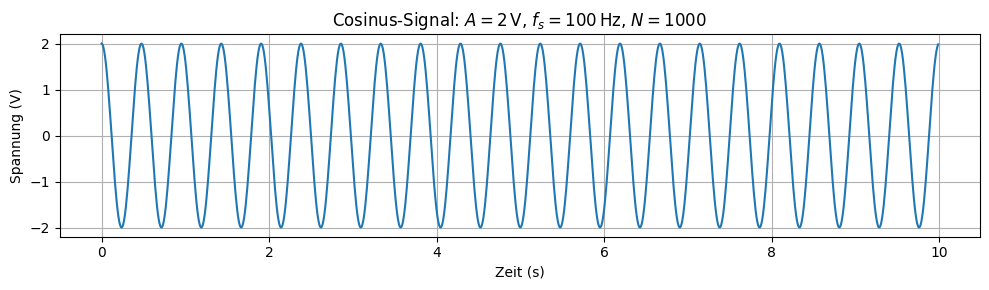

In [15]:
import numpy as np
import matplotlib.pyplot as plt

A = 2.0       # Amplitude in V
fs = 100.0    # Abtastrate in Hz
N = 1000      # Anzahl Samples
f = 2.1       # Signalfrequenz in Hz (Beispiel)

T = N / fs    # Zeitdauer in s
t = np.linspace(0, T, N, endpoint=False)  # Zeitpunkte ohne rechten Endpunkt
v = A * np.cos(2 * np.pi * f * t)

plt.figure(figsize=(10, 3))
plt.plot(t, v, color="C0")
plt.xlabel("Zeit (s)")
plt.ylabel("Spannung (V)")
plt.title(r"Cosinus-Signal: $A = 2\,\mathrm{V}$, $f_s = 100\,\mathrm{Hz}$, $N = 1000$")
plt.grid(True)
plt.tight_layout()
plt.show()

## Momentanleistung am Widerstand $R = 50\,\Omega$

Fällt die Spannung $v(t)$ an einem ohmschen Widerstand $R$ ab, ist die **Momentanleistung**:
$$ p(t) = \frac{v(t)^2}{R} $$

Wir berechnen $p(t)$ für alle Abtastzeitpunkte und plotten sie.

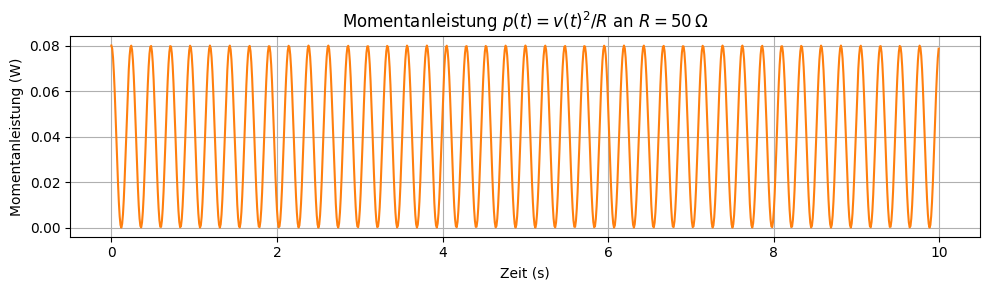

In [16]:
R = 50.0   # Widerstand in Ohm
p = v ** 2 / R

plt.figure(figsize=(10, 3))
plt.plot(t, p, color="C1")
plt.xlabel("Zeit (s)")
plt.ylabel("Momentanleistung (W)")
plt.title(r"Momentanleistung $p(t) = v(t)^2 / R$ an $R = 50\,\Omega$")
plt.grid(True)
plt.tight_layout()
plt.show()

### Doppelte Frequenz im Leistungsverlauf

Vergleicht man den **Verlauf der Spannung** $v(t)$ und den der **Momentanleistung** $p(t) = v(t)^2/R$, fällt auf: Der **Leistungsverlauf hat die doppelte Frequenz** des Spannungsverlaufs.

Das lässt sich mit der **trigonometrischen Formel** für $\cos^2$ erklären:
$$ \cos^2(\alpha) = \frac{1 + \cos(2\alpha)}{2} $$

Mit $\alpha = 2\pi f\,t$ folgt $v(t)^2 = A^2 \cos^2(2\pi f\,t) = A^2/2 \cdot (1 + \cos(4\pi f\,t))$. Der zeitabhängige Anteil hat also die Frequenz $2f$ – doppelt so hoch wie die Signalfrequenz $f$. Die Leistung oszilliert daher mit $2f$ um ihren Mittelwert $A^2/(2R)$.

### Zwei Kurven in einem Diagramm (Matplotlib-Syntax)

Um **zwei Funktionen** (z. B. Spannung und Leistung) **in einem gemeinsamen Plot** darzustellen, ruft man **mehrmals** `plt.plot(...)` auf – jede Kurve wird der gleichen **Figure** und den gleichen **Axes** (Achsen) hinzugefügt. Matplotlib skaliert die **y-Achse** automatisch so, dass alle gezeichneten Werte sichtbar sind. Wenn die Wertebereiche sehr unterschiedlich sind (z. B. Spannung in V, Leistung in W), dominiert oft eine Kurve die Skalierung; dann kann man mit **`ax.twinx()`** eine zweite y-Achse rechts erzeugen (hier verzichten wir darauf und nutzen eine gemeinsame Achse mit zwei Legenden).

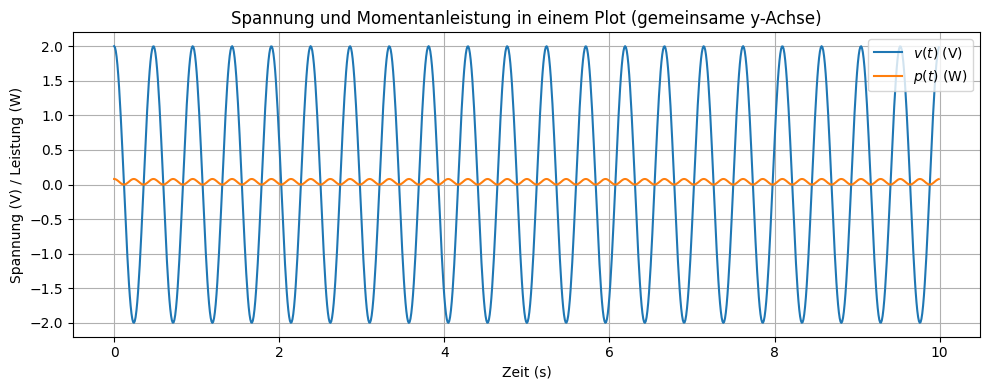

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(t, v, color="C0", label=r"$v(t)$ (V)")
plt.plot(t, p, color="C1", label=r"$p(t)$ (W)")
plt.xlabel("Zeit (s)")
plt.ylabel("Spannung (V) / Leistung (W)")
plt.title("Spannung und Momentanleistung in einem Plot (gemeinsame y-Achse)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

## Durchschnittliche Leistung

Die **durchschnittliche Leistung** über die Zeitdauer $T$ (diskret mit $N$ Werten, $\Delta t = T/N$):
$$ P_{\mathrm{avg}} = \frac{1}{T} \int_0^T p(t)\,\mathrm{d}t \approx \frac{1}{N} \sum_{n=0}^{N-1} p(t_n) $$

Für ein Cosinus-Signal $v(t) = A\cos(2\pi f t)$ gilt theoretisch $P_{\mathrm{avg}} = A^2/(2R)$.

**Einfache Mittlung mit NumPy:** Mit **`np.mean(p)`** berechnest du den Durchschnitt aller Werte im Array `p`. Das ist eine sehr einfache und effiziente Art, den Mittelwert zu ermitteln – ein **Vorteil von NumPy-Arrays**: Statt eine Schleife zu schreiben, übergibst du das komplette Array und erhältst sofort das Ergebnis. Für diskret abgetastete Signale entspricht das genau der obigen Summe $\frac{1}{N}\sum p(t_n)$.

## Subplots: Figure und Axes in Matplotlib

In Matplotlib unterscheidet man zwischen **Figure** (die gesamte Zeichenfläche/Fenster) und **Axes** (ein einzelnes Koordinatensystem mit x-/y-Achse innerhalb der Figure).

- **Figure** (`plt.figure()` oder `fig`): Der „Container“, der eine oder mehrere Axes sowie Titel, Legenden etc. umfasst.
- **Axes** (`ax`): Ein **Achsen-Objekt**, in das du z. B. mit `ax.plot(...)`, `ax.hist(...)` zeichnest. Bei einem einzelnen Plot erzeugt `plt.plot(...)` automatisch eine Figure und eine Axes.

**Subplots** sind mehrere Axes in einer Figure. Du erzeugt sie z. B. mit **`fig, axes = plt.subplots(Zeilen, Spalten)`**. Dann ist `axes` ein Array von Axes-Objekten (oder ein einzelnes, wenn Zeilen=Spalten=1). Du zeichnest in eine bestimmte Axe mit z. B. `axes[0].plot(...)` oder `ax1.plot(...)` bei **`fig, (ax1, ax2) = plt.subplots(1, 2)`**. So kannst du mehrere Diagramme nebeneinander oder untereinander anordnen – wie beim Amplituden- und Leistungs-Histogramm weiter unten.

## Histogramme: Amplituden- und Leistungsverteilung


In [18]:
P_avg = np.mean(p)
P_avg_theorie = (A ** 2) / (2 * R)

print("Durchschnittliche Leistung (numerisch):", round(P_avg, 6), "W")
print("Theorie (Cosinus): A²/(2R) =", round(P_avg_theorie, 6), "W")

Durchschnittliche Leistung (numerisch): 0.04 W
Theorie (Cosinus): A²/(2R) = 0.04 W


## Histogramme: Amplituden- und Leistungsverteilung

Ein **Histogramm** zeigt, wie oft Werte in bestimmte **Bereiche („Bins“)** fallen. So siehst du die **Verteilung** der Amplituden bzw. der Momentanleistung.

### `plt.hist` – Kurzerklärung

- **`plt.hist(x, bins=...)`**: `x` = Daten-Array; `bins` = Anzahl der Klassen oder eine Folge von Bin-Grenzen.
- **`density=True`**: Normiert die Fläche unter dem Histogramm auf 1 („Wahrscheinlichkeitsdichte“). Ohne `density`: absolute Häufigkeiten.
- **`color`, `alpha`, `label`**: Optik und Legende.
- **`edgecolor`**: Rand der Balken (z. B. `'black'` oder `'none'`).

Histogramme eignen sich für **Verteilungen** (z. B. Amplituden über die Zeit, Leistungswerte) und in der KT z. B. für Rauschverteilungen oder Signalpegel.

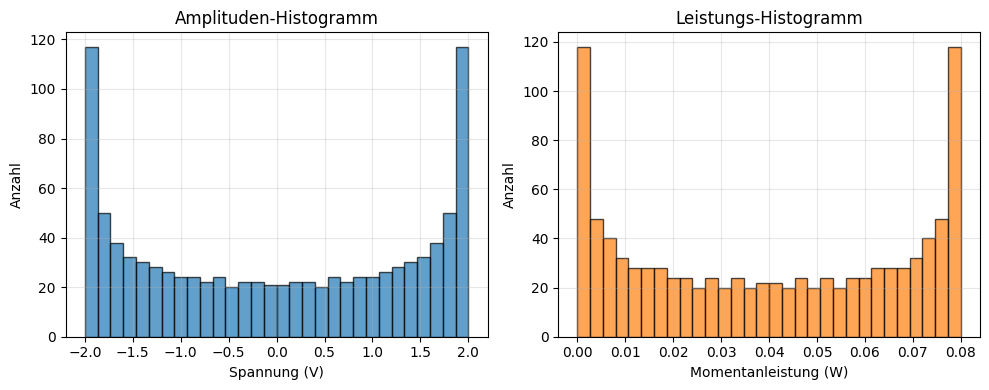

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Amplituden-Histogramm (Spannung v)
ax1.hist(v, bins=30, color="C0", alpha=0.7, edgecolor="black")
ax1.set_xlabel("Spannung (V)")
ax1.set_ylabel("Anzahl")
ax1.set_title("Amplituden-Histogramm")
ax1.grid(True, alpha=0.3)

# Leistungs-Histogramm
ax2.hist(p, bins=30, color="C1", alpha=0.7, edgecolor="black")
ax2.set_xlabel("Momentanleistung (W)")
ax2.set_ylabel("Anzahl")
ax2.set_title("Leistungs-Histogramm")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Beim Cosinus liegen die **Spannungswerte** symmetrisch um null (viele Werte nahe $+A$ und $-A$). Die **Momentanleistung** $p = v^2/R$ ist immer $\ge 0$; sie ist bei $|v| = A$ am größten und bei $v = 0$ null – das Histogramm der Leistung zeigt entsprechend eine Verteilung zwischen 0 und $A^2/R$.

---

**Zurück:** [← 06_Plotten (Hauptkapitel)](06_Plotten.ipynb)